In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn nltk transformers datasets

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("All libraries imported successfully")

All libraries imported successfully


In [ ]:
import pandas as pd

fake_df = pd.read_csv("/content/Fake.csv")
true_df = pd.read_csv("/content/True.csv")

print("Fake News Dataset:", fake_df.shape)
print("Real News Dataset:", true_df.shape)

Fake News Dataset: (23481, 4)
Real News Dataset: (21417, 4)


In [ ]:
print("Fake News Columns:")
print(fake_df.columns.tolist())

print("\nReal News Columns:")
print(true_df.columns.tolist())

Fake News Columns:
['title', 'text', 'subject', 'date']

Real News Columns:
['title', 'text', 'subject', 'date']


In [ ]:
print("Fake News:")
display(fake_df.head())

print("Real News:")
display(true_df.head())

Fake News:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


Real News:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
print("Fake News Missing Values:")
print(fake_df.isnull().sum())

print("\nReal News Missing Values:")
print(true_df.isnull().sum())

Fake News Missing Values:
title      0
text       0
subject    0
date       0
dtype: int64

Real News Missing Values:
title      0
text       0
subject    0
date       0
dtype: int64


In [ ]:
print("Fake News Records:", len(fake_df))
print("Real News Records:", len(true_df))
print("Total Records:", len(fake_df) + len(true_df))

Fake News Records: 23481
Real News Records: 21417
Total Records: 44898


Fake News: 23481
Real News: 21417


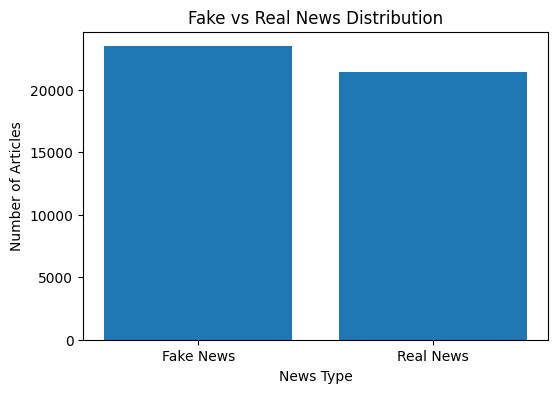

In [ ]:
import matplotlib.pyplot as plt

fake_count = len(fake_df)
real_count = len(true_df)

print("Fake News:", fake_count)
print("Real News:", real_count)

plt.figure(figsize=(6, 4))
plt.bar(["Fake News", "Real News"], [fake_count, real_count])
plt.title("Fake vs Real News Distribution")
plt.xlabel("News Type")
plt.ylabel("Number of Articles")
plt.show()

In [ ]:
fake_df["label"] = 0
true_df["label"] = 1

print("Fake label:", fake_df["label"].unique())
print("Real label:", true_df["label"].unique())

Fake label: [0]
Real label: [1]


In [ ]:
df = pd.concat([fake_df, true_df], ignore_index=True)

print("Total records:", len(df))
print("Dataset shape:", df.shape)

Total records: 44898
Dataset shape: (44898, 5)


In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.head())

                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  
3         May 22, 2017      0  
4       June 24, 2016       1  


In [ ]:
print(df["label"].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [ ]:
print(df.columns.tolist())

['title', 'text', 'subject', 'date', 'label']


In [ ]:
df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")

print(df[["title", "text", "content", "label"]].head())

                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text  \
0  21st Century Wire says Ben Stein, reputable pr...   
1  WASHINGTON (Reuters) - U.S. President Donald T...   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...   
3  On Monday, Donald Trump once again embarrassed...   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...   

                                             content  label  
0  Ben Stein Calls Out 9th Circuit Court: Committ...      0  
1  Trump drops Steve Bannon from National Securit...      1  
2  Puerto Rico expects U.S. to lift Jones Act shi...      1  
3   OOPS: Trump Just Accidentally Confirmed He Le...      0  
4  Donald Trump 

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [ ]:
df["clean_text"] = df["content"].apply(clean_text)

print(df[["content", "clean_text", "label"]].head())

                                             content  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                          clean_text  label  
0  ben stein calls out th circuit court committed...      0  
1  trump drops steve bannon from national securit...      1  
2  puerto rico expects us to lift jones act shipp...      1  
3  oops trump just accidentally confirmed he leak...      0  
4  donald trump heads for scotland to reopen a go...      1  


In [ ]:
print("Empty text:", (df["clean_text"].str.len() == 0).sum())

Empty text: 9


In [ ]:
print("Duplicate articles:", df["clean_text"].duplicated().sum())

Duplicate articles: 5822


In [ ]:
print(df[["clean_text", "label"]].head())
print("\nDataset shape:", df.shape)

                                          clean_text  label
0  ben stein calls out th circuit court committed...      0
1  trump drops steve bannon from national securit...      1
2  puerto rico expects us to lift jones act shipp...      1
3  oops trump just accidentally confirmed he leak...      0
4  donald trump heads for scotland to reopen a go...      1

Dataset shape: (44898, 7)


In [ ]:
before = len(df)

df = df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True)

after = len(df)

print("Records before removing duplicates:", before)
print("Records after removing duplicates:", after)
print("Duplicates removed:", before - after)

Records before removing duplicates: 44898
Records after removing duplicates: 39076
Duplicates removed: 5822


In [ ]:
print("Fake News:", (df["label"] == 0).sum())
print("Real News:", (df["label"] == 1).sum())

Fake News: 17901
Real News: 21175


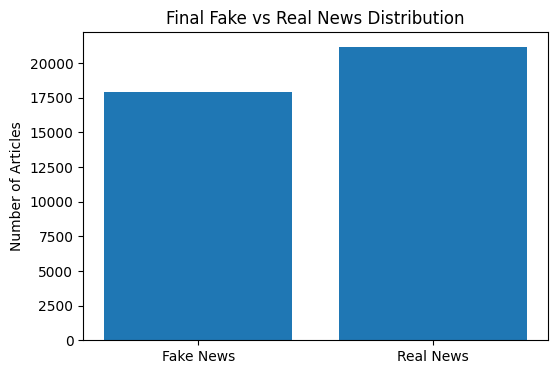

In [ ]:
import matplotlib.pyplot as plt

label_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Fake News", "Real News"], label_counts.values)
plt.title("Final Fake vs Real News Distribution")
plt.ylabel("Number of Articles")
plt.show()

In [ ]:
X = df["clean_text"]
y = df["label"]

print("Total samples:", len(X))
print("Total labels:", len(y))

Total samples: 39076
Total labels: 39076


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Temporary samples:", len(X_temp))

Training samples: 31260
Temporary samples: 7816


In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 31260
Validation samples: 3908
Testing samples: 3908


In [ ]:
print("Dataset Split")
print("----------------")
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))
print("Total:", len(X_train) + len(X_val) + len(X_test))
print("Original:", len(df))

Dataset Split
----------------
Train: 31260
Validation: 3908
Test: 3908
Total: 39076
Original: 39076


In [ ]:
import nltk
from collections import Counter

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
MAX_VOCAB_SIZE = 20000

counter = Counter()

for text in X_train:
    tokens = nltk.word_tokenize(text)
    counter.update(tokens)

most_common_words = counter.most_common(MAX_VOCAB_SIZE)

word_to_index = {
    word: index + 2
    for index, (word, _) in enumerate(most_common_words)
}

word_to_index["<PAD>"] = 0
word_to_index["<UNK>"] = 1

vocab_size = len(word_to_index)

print("Vocabulary size:", vocab_size)
print("PAD index:", word_to_index["<PAD>"])
print("UNK index:", word_to_index["<UNK>"])

Vocabulary size: 20002
PAD index: 0
UNK index: 1


In [ ]:
def text_to_sequence(text):
    tokens = nltk.word_tokenize(text)
    return [
        word_to_index.get(token, word_to_index["<UNK>"])
        for token in tokens
    ]

In [ ]:
sample_text = X_train.iloc[0]
sample_sequence = text_to_sequence(sample_text)

print("Original text:")
print(sample_text[:300])

print("\nNumerical sequence:")
print(sample_sequence[:30])

Original text:
senate tax bill stalls on deficitfocused trigger washington reuters the us senate on thursday delayed voting on a republican tax overhaul as the bill was tripped up by problems with an amendment sought by fiscal hawks to address a large expansion of the federal budget deficit projected to result fro

Numerical sequence:
[141, 177, 144, 15623, 9, 1, 3649, 108, 60, 2, 30, 141, 9, 200, 3744, 606, 9, 5, 73, 177, 1978, 19, 2, 144, 18, 1, 68, 21, 1042, 17]


In [ ]:
MAX_LENGTH = 300

def pad_sequence(sequence, max_length=MAX_LENGTH):
    if len(sequence) > max_length:
        return sequence[:max_length]

    return sequence + [word_to_index["<PAD>"]] * (max_length - len(sequence))

In [ ]:
padded_sample = pad_sequence(sample_sequence)

print("Original sequence length:", len(sample_sequence))
print("Padded sequence length:", len(padded_sample))
print("First 30 values:", padded_sample[:30])

Original sequence length: 984
Padded sequence length: 300
First 30 values: [141, 177, 144, 15623, 9, 1, 3649, 108, 60, 2, 30, 141, 9, 200, 3744, 606, 9, 5, 73, 177, 1978, 19, 2, 144, 18, 1, 68, 21, 1042, 17]


In [ ]:
X_train_seq = [pad_sequence(text_to_sequence(text)) for text in X_train]
X_val_seq = [pad_sequence(text_to_sequence(text)) for text in X_val]
X_test_seq = [pad_sequence(text_to_sequence(text)) for text in X_test]

print("Training samples:", len(X_train_seq))
print("Validation samples:", len(X_val_seq))
print("Testing samples:", len(X_test_seq))
print("Sequence length:", len(X_train_seq[0]))

Training samples: 31260
Validation samples: 3908
Testing samples: 3908
Sequence length: 300


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_seq, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.long)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

print("X_train shape:", X_train_tensor.shape)
print("X_val shape:", X_val_tensor.shape)
print("X_test shape:", X_test_tensor.shape)

print("y_train shape:", y_train_tensor.shape)

X_train shape: torch.Size([31260, 300])
X_val shape: torch.Size([3908, 300])
X_test shape: torch.Size([3908, 300])
y_train shape: torch.Size([31260])


In [ ]:
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.texts[index], self.labels[index]

In [ ]:
train_dataset = FakeNewsDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = FakeNewsDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = FakeNewsDataset(
    X_test_tensor,
    y_test_tensor
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Testing dataset:", len(test_dataset))

Training dataset: 31260
Validation dataset: 3908
Testing dataset: 3908


In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 489
Validation batches: 62
Test batches: 62


In [ ]:
sample_batch, sample_labels = next(iter(train_loader))

print("Batch shape:", sample_batch.shape)
print("Labels shape:", sample_labels.shape)
print("First 10 labels:", sample_labels[:10])

Batch shape: torch.Size([64, 300])
Labels shape: torch.Size([64])
First 10 labels: tensor([1., 0., 1., 0., 0., 1., 1., 0., 0., 1.])


In [ ]:
import torch.nn as nn

print("PyTorch Neural Network module ready")

PyTorch Neural Network module ready


In [ ]:
class LSTMFakeNewsClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128, num_layers=2, dropout=0.3):
        super(LSTMFakeNewsClassifier, self).__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.embedding(x)

        output, (hidden, cell) = self.lstm(embedded)

        last_hidden = hidden[-1]

        dropped = self.dropout(last_hidden)

        output = self.fc(dropped)

        return output.squeeze(1)

In [ ]:
model = LSTMFakeNewsClassifier(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3
)

model = model.to(device)

print(model)

LSTMFakeNewsClassifier(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 2824577
Trainable parameters: 2824577


In [ ]:
sample_batch, sample_labels = next(iter(train_loader))

sample_batch = sample_batch.to(device)

with torch.no_grad():
    output = model(sample_batch)

print("Input shape:", sample_batch.shape)
print("Output shape:", output.shape)
print("First 5 outputs:", output[:5])

Input shape: torch.Size([64, 300])
Output shape: torch.Size([64])
First 5 outputs: tensor([0.1010, 0.0607, 0.0912, 0.0727, 0.0639], device='cuda:0')


In [ ]:
criterion = nn.BCEWithLogitsLoss()

print("Loss function:", criterion)

Loss function: BCEWithLogitsLoss()


In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer: Adam")
print("Learning rate:", 0.001)

Optimizer: Adam
Learning rate: 0.001


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for texts, labels in loader:
        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(texts)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = (torch.sigmoid(outputs) >= 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = total_loss / len(loader)
    accuracy = correct / total

    return average_loss, accuracy

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            predictions = (torch.sigmoid(outputs) >= 0.5).float()

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    average_loss = total_loss / len(loader)
    accuracy = correct / total

    return average_loss, accuracy

In [ ]:
EPOCHS = 5

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 1/5 | Train Loss: 0.6103 | Train Accuracy: 0.6817 | Val Loss: 0.6013 | Val Accuracy: 0.6978
Epoch 2/5 | Train Loss: 0.5596 | Train Accuracy: 0.6940 | Val Loss: 0.6562 | Val Accuracy: 0.5857
Epoch 3/5 | Train Loss: 0.5045 | Train Accuracy: 0.7498 | Val Loss: 0.3261 | Val Accuracy: 0.8621
Epoch 4/5 | Train Loss: 0.3537 | Train Accuracy: 0.8472 | Val Loss: 0.5471 | Val Accuracy: 0.6863
Epoch 5/5 | Train Loss: 0.3827 | Train Accuracy: 0.8272 | Val Loss: 0.1803 | Val Accuracy: 0.9440


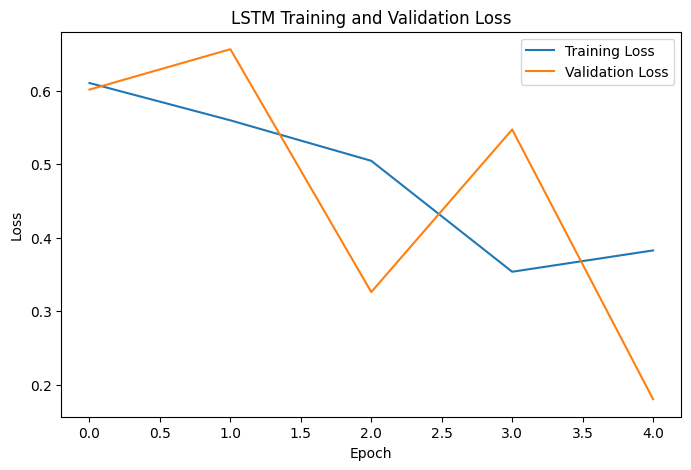

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.show()

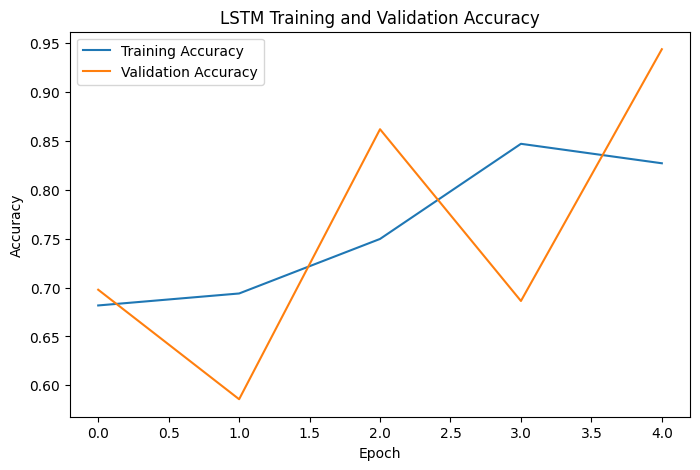

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)

        outputs = model(texts)

        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).long()

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Predictions generated successfully")

Predictions generated successfully


In [ ]:
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)

print("LSTM Test Results")
print("------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

LSTM Test Results
------------------
Accuracy : 0.9534
Precision: 0.9416
Recall   : 0.9745
F1-Score : 0.9578


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Fake News", "Real News"]
    )
)

              precision    recall  f1-score   support

   Fake News       0.97      0.93      0.95      1791
   Real News       0.94      0.97      0.96      2117

    accuracy                           0.95      3908
   macro avg       0.96      0.95      0.95      3908
weighted avg       0.95      0.95      0.95      3908



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_predictions)

print(cm)

[[1663  128]
 [  54 2063]]


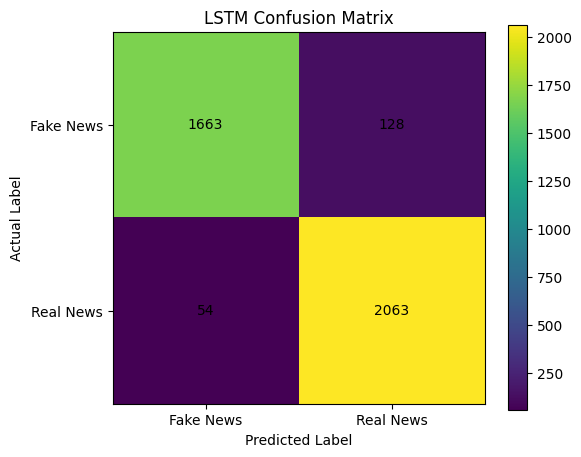

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Fake News", "Real News"])
plt.yticks([0, 1], ["Fake News", "Real News"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [ ]:
lstm_results = {
    "Model": "LSTM",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}

print(lstm_results)

{'Model': 'LSTM', 'Accuracy': 0.9534288638689867, 'Precision': 0.9415791875855773, 'Recall': 0.9744922059518186, 'F1-Score': 0.957753017641597}


In [ ]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
fake_df = pd.read_csv("/content/Fake.csv")
real_df = pd.read_csv("/content/True.csv")

print("Fake:", fake_df.shape)
print("Real:", real_df.shape)

Fake: (23481, 4)
Real: (21417, 4)


In [ ]:
fake_df["label"] = 0
real_df["label"] = 1

fake_df["content"] = fake_df["title"].fillna("") + " " + fake_df["text"].fillna("")
real_df["content"] = real_df["title"].fillna("") + " " + real_df["text"].fillna("")

data = pd.concat(
    [
        fake_df[["content", "label"]],
        real_df[["content", "label"]]
    ],
    ignore_index=True
)

data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total samples:", len(data))
print(data["label"].value_counts())

Total samples: 44898
label
0    23481
1    21417
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = data["content"]
y = data["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 35918
Validation: 4490
Test: 4490


In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

print("Tokenizer ready")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer ready


In [ ]:
class BERTFakeNewsDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        text = str(self.texts.iloc[index])
        label = int(self.labels.iloc[index])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

print("Dataset class ready")

Dataset class ready


In [ ]:
bert_train_dataset = BERTFakeNewsDataset(
    X_train, y_train, tokenizer
)

bert_val_dataset = BERTFakeNewsDataset(
    X_val, y_val, tokenizer
)

bert_test_dataset = BERTFakeNewsDataset(
    X_test, y_test, tokenizer
)

print("Train:", len(bert_train_dataset))
print("Validation:", len(bert_val_dataset))
print("Test:", len(bert_test_dataset))

Train: 35918
Validation: 4490
Test: 4490


In [ ]:
BERT_BATCH_SIZE = 8

bert_train_loader = DataLoader(
    bert_train_dataset,
    batch_size=BERT_BATCH_SIZE,
    shuffle=True
)

bert_val_loader = DataLoader(
    bert_val_dataset,
    batch_size=BERT_BATCH_SIZE,
    shuffle=False
)

bert_test_loader = DataLoader(
    bert_test_dataset,
    batch_size=BERT_BATCH_SIZE,
    shuffle=False
)

print("DataLoaders ready")

DataLoaders ready


In [ ]:
batch = next(iter(bert_train_loader))

print("Input:", batch["input_ids"].shape)
print("Mask:", batch["attention_mask"].shape)
print("Labels:", batch["labels"].shape)

Input: torch.Size([8, 128])
Mask: torch.Size([8, 128])
Labels: torch.Size([8])


In [ ]:
bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

bert_model = bert_model.to(device)

print("BERT model ready")
print("Device:", next(bert_model.parameters()).device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model ready
Device: cuda:0


In [ ]:
bert_optimizer = AdamW(
    bert_model.parameters(),
    lr=2e-5
)

print("Optimizer ready")

Optimizer ready


In [ ]:
def train_bert(model, loader, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(outputs.logits, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

print("Training function ready")

Training function ready


In [ ]:
def evaluate_bert(model, loader, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()

            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

print("Validation function ready")

Validation function ready


In [ ]:
BERT_EPOCHS = 1

bert_train_losses = []
bert_train_accuracies = []
bert_val_losses = []
bert_val_accuracies = []

for epoch in range(BERT_EPOCHS):

    train_loss, train_accuracy = train_bert(
        bert_model,
        bert_train_loader,
        bert_optimizer,

        device
    )


    val_loss, val_accuracy = evaluate_bert(
        bert_model,
        bert_val_loader,
        device
    )

    bert_train_losses.append(train_loss)
    bert_train_accuracies.append(train_accuracy)
    bert_val_losses.append(val_loss)
    bert_val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch + 1}/{BERT_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 1/1 | Train Loss: 0.0094 | Train Accuracy: 0.9978 | Val Loss: 0.0025 | Val Accuracy: 0.9996


In [ ]:
def evaluate_bert(model, loader, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()

            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

print("Evaluation function ready")

Evaluation function ready


In [ ]:
print("bert_model" in globals())
print("bert_test_loader" in globals())
print("device" in globals())

True
True
True


In [ ]:
test_loss, test_accuracy = evaluate_bert(
    bert_model,
    bert_test_loader,
    device
)

print(f"BERT Test Loss: {test_loss:.4f}")
print(f"BERT Test Accuracy: {test_accuracy:.4f}")

BERT Test Loss: 0.0031
BERT Test Accuracy: 0.9996


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

bert_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in bert_test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

bert_precision = precision_score(
    all_labels,
    all_predictions,
    zero_division=0
)

bert_recall = recall_score(
    all_labels,
    all_predictions,
    zero_division=0
)

bert_f1 = f1_score(
    all_labels,
    all_predictions,
    zero_division=0
)

print(f"BERT Precision: {bert_precision:.4f}")
print(f"BERT Recall: {bert_recall:.4f}")
print(f"BERT F1 Score: {bert_f1:.4f}")

BERT Precision: 1.0000
BERT Recall: 0.9991
BERT F1 Score: 0.9995


BERT Confusion Matrix:
[[2348    0]
 [   2 2140]]


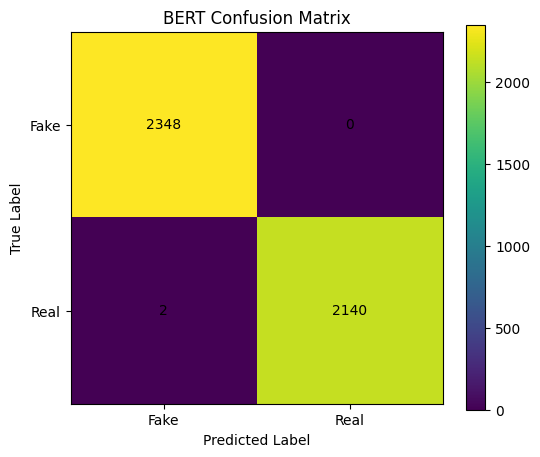

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("BERT Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("BERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Fake", "Real"])
plt.yticks([0, 1], ["Fake", "Real"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CNN-LSTM setup ready")
print("Device:", device)

CNN-LSTM setup ready
Device: cuda
